Step 1: Load the Dataset into Google Colab

In [6]:
import os , sys

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
os.chdir('/content/drive/MyDrive')

sys.path.append("/content/drive/My Drive/")

Step 2: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Step 3: Read the Dataset

In [8]:
dataset = pd.read_csv('cardata.csv')

In [9]:
dataset

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


Step 4: Create Independent and Dependent Variables

In [10]:
X = dataset.iloc[:, 3:4]   # Present_Price (independent variable)
y = dataset.iloc[:, 2]     # Selling_Price (dependent variable)

In [11]:
X

,Present_Price
0,5.59
1,9.54
2,9.85
3,4.15
4,6.87
...,...
296,11.60
297,5.90
298,11.00
299,12.50


In [12]:
y

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


Step 5: Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Step 6: Apply Polynomial Transformation

In [14]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

Step 7: Train Polynomial Regression Model

In [15]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test_poly)

Step 8: Evaluate Model

In [17]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6747632285185114


Step 9: Visualization


/tmp/ipykernel_403/3938687084.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


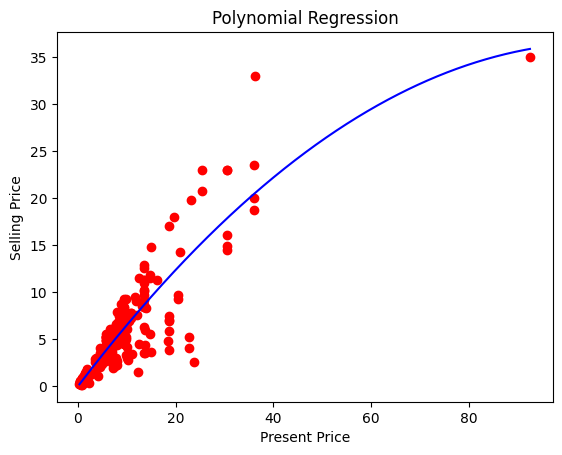

In [25]:
# Create smooth curve
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)

# Transform to polynomial
X_grid_poly = poly.transform(X_grid)

# Plot
plt.scatter(X, y, color='red')
plt.plot(X_grid, model.predict(X_grid_poly), color='blue')

plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Polynomial Regression")
plt.show()